<a href="https://colab.research.google.com/github/leilacielok/market_basket_analysis/blob/main/project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Algorithms for Massive Data - Market-Basket Analysis

In [81]:
import os
import pandas as pd
import time
import matplotlib.pyplot as plt

from google.colab import userdata
from itertools import combinations
from collections import Counter

In [82]:
os.environ["KAGGLE_USERNAME"] = userdata.get("KAGGLE_USERNAME")
os.environ["KAGGLE_KEY"] = userdata.get("KAGGLE_KEY")


# SOSTITUIRE CON: Insert your Kaggle credentials before running
# os.environ['KAGGLE_USERNAME'] = "xxxx"
# os.environ['KAGGLE_KEY'] = "xxxx"

!kaggle datasets download -d harshitshankhdhar/imdb-dataset-of-top-1000-movies-and-tv-shows
!unzip -o -q imdb-dataset-of-top-1000-movies-and-tv-shows.zip -d imdb_data

print("Dataset downloaded and extracted.")

Dataset URL: https://www.kaggle.com/datasets/harshitshankhdhar/imdb-dataset-of-top-1000-movies-and-tv-shows
License(s): CC0-1.0
imdb-dataset-of-top-1000-movies-and-tv-shows.zip: Skipping, found more recently modified local copy (use --force to force download)
Dataset downloaded and extracted.


In [83]:
csv_path = os.path.join(
    "imdb_data",
    "imdb_top_1000.csv"
)

df = pd.read_csv(csv_path)

In [84]:
# Minimum support threshold
MIN_SUPPORT_RATIO = 0.005
MIN_SUPPORT_COUNT = int(len(df) * MIN_SUPPORT_RATIO)

print("Minimum support count:", MIN_SUPPORT_COUNT)

Minimum support count: 5


In [85]:
# Basket construction
STAR_COLS = ["Star1", "Star2", "Star3", "Star4"]

baskets = []

for _, row in df.iterrows():
    basket = []

    for col in STAR_COLS:
        actor = row[col]
        basket.append(actor)

    baskets.append(set(basket))

print("Number of baskets:", len(baskets))
print("Example basket:", baskets[0])

Number of baskets: 1000
Example basket: {'Morgan Freeman', 'Bob Gunton', 'Tim Robbins', 'William Sadler'}


## A-Priori Algorithm

In [ ]:
def apriori(baskets, support_threshold):

    # FIRST PASS
    # Translate item names into integers

    names2int = {}
    int2names = {}
    item_id = 0

    for basket in baskets:
        for item in basket:
            if item not in names2int:
                names2int[item] = item_id
                int2names[item_id] = item
                item_id += 1

    # Use integers as indexes in the counts array
    counts = [0] * len(names2int)

    for basket in baskets:
        for item in basket:
            item_integer = names2int[item]
            counts[item_integer] += 1

    # IN-BETWEEN PASSES
    # Create frequent-items table

    frequent_items_table = [0] * len(counts)
    frequent_singletons = {}

    new_number = 1
    newint2name = {}

    for item_integer, count in enumerate(counts):
        if count >= support_threshold:
            frequent_items_table[item_integer] = new_number
            newint2name[new_number] = int2names[item_integer]
            frequent_singletons[frozenset([int2names[item_integer]])] = count
            new_number += 1

    # SECOND PASS
    # Count all pairs of frequent items

    pair_counts = {}

    for basket in baskets:

        # a. Find frequent items in the basket
        frequent_items_in_basket = []

        for item in basket:
            old_integer = names2int[item]
            new_integer = frequent_items_table[old_integer]

            if new_integer != 0:
                frequent_items_in_basket.append(new_integer)

        # b. Generate all pairs of frequent items
        for i in range(len(frequent_items_in_basket)):
            for j in range(i + 1, len(frequent_items_in_basket)):

                item1 = frequent_items_in_basket[i]
                item2 = frequent_items_in_basket[j]
                pair = tuple(sorted((item1, item2)))

                if pair not in pair_counts:
                    pair_counts[pair] = 0

                pair_counts[pair] += 1

    frequent_pairs = {}

    for pair, count in pair_counts.items():
        if count >= support_threshold:
            actor1 = newint2name[pair[0]]
            actor2 = newint2name[pair[1]]

            frequent_pairs[frozenset([actor1, actor2])] = count

     # THIRD PASS
     # Count triples generated from frequent pairs

    triple_counts = {}

    frequent_pair_sets = set(frequent_pairs.keys())

    for basket in baskets:

        frequent_items_in_basket = []

        for item in basket:
            old_integer = names2int[item]
            new_integer = frequent_items_table[old_integer]

            if new_integer != 0:
                frequent_items_in_basket.append(item)

        for triple in combinations(frequent_items_in_basket, 3):
          triple = frozenset(triple)
          if all(
              frozenset(pair) in frequent_pair_sets
              for pair in combinations(triple, 2)
              ):
                triple_counts[triple] = triple_counts.get(triple, 0) + 1

    frequent_triples = {}

    for triple, count in triple_counts.items():
        if count >= support_threshold:
            frequent_triples[triple] = count

    frequent_itemsets = {}

    frequent_itemsets[1] = frequent_singletons

    if frequent_pairs:
        frequent_itemsets[2] = frequent_pairs
    if frequent_triples:
        frequent_itemsets[3] = frequent_triples

    return frequent_itemsets

In [ ]:
# Display frequent itemsets
frequent_itemsets = apriori(
    baskets,
    MIN_SUPPORT_COUNT
)

for size, itemsets in frequent_itemsets.items():
    print("\n" + "=" * 50)
    print(f"Frequent itemsets of size {size}")
    print("=" * 50)

    sorted_itemsets = sorted(
        itemsets.items(),
        key=lambda x: x[1],
        reverse=True
    )

    for itemset, count in sorted_itemsets:
        print(set(itemset), "-> support count:", count)


Frequent itemsets of size 1
{'Robert De Niro'} -> support count: 17
{'Tom Hanks'} -> support count: 14
{'Al Pacino'} -> support count: 13
{'Brad Pitt'} -> support count: 12
{'Clint Eastwood'} -> support count: 12
{'Christian Bale'} -> support count: 11
{'Leonardo DiCaprio'} -> support count: 11
{'Matt Damon'} -> support count: 11
{'James Stewart'} -> support count: 10
{'Michael Caine'} -> support count: 9
{'Scarlett Johansson'} -> support count: 9
{'Humphrey Bogart'} -> support count: 9
{'Ethan Hawke'} -> support count: 9
{'Johnny Depp'} -> support count: 9
{'Denzel Washington'} -> support count: 9
{'Harrison Ford'} -> support count: 8
{'Aamir Khan'} -> support count: 8
{'Morgan Freeman'} -> support count: 7
{'Ian McKellen'} -> support count: 7
{'Bruce Willis'} -> support count: 7
{'Edward Norton'} -> support count: 7
{'Toshirô Mifune'} -> support count: 7
{'Russell Crowe'} -> support count: 7
{'Mark Ruffalo'} -> support count: 7
{'Robert Downey Jr.'} -> support count: 7
{'Cary Grant'

# PROVA: MODULARIZZARE PRIMI DUE STEP PER A-PRIORI E TERZO STEP COMUNE A PRIORI E PCY

## A PRIORI

In [86]:
def find_frequent_singletons(baskets, support_threshold):

    names2int = {}
    int2names = {}
    item_id = 0

    for basket in baskets:
        for item in basket:
            if item not in names2int:
                names2int[item] = item_id
                int2names[item_id] = item
                item_id += 1

    counts = [0] * len(names2int)

    for basket in baskets:
        for item in basket:
            item_integer = names2int[item]
            counts[item_integer] += 1

    frequent_items_table = [0] * len(counts)
    frequent_singletons = {}

    new_number = 1
    newint2name = {}

    for item_integer, count in enumerate(counts):
        if count >= support_threshold:
            frequent_items_table[item_integer] = new_number
            newint2name[new_number] = int2names[item_integer]
            frequent_singletons[frozenset([int2names[item_integer]])] = count
            new_number += 1

    return names2int, frequent_items_table, newint2name, frequent_singletons

In [87]:
def find_frequent_pairs_apriori(
    baskets,
    support_threshold,
    names2int,
    frequent_items_table,
    newint2name
):

    pair_counts = {}

    for basket in baskets:

        frequent_items_in_basket = []

        for item in basket:
            old_integer = names2int[item]
            new_integer = frequent_items_table[old_integer]

            if new_integer != 0:
                frequent_items_in_basket.append(new_integer)

        for i in range(len(frequent_items_in_basket)):
            for j in range(i + 1, len(frequent_items_in_basket)):

                item1 = frequent_items_in_basket[i]
                item2 = frequent_items_in_basket[j]

                pair = tuple(sorted((item1, item2)))

                pair_counts[pair] = pair_counts.get(pair, 0) + 1

    frequent_pairs = {}

    for pair, count in pair_counts.items():
        if count >= support_threshold:
            actor1 = newint2name[pair[0]]
            actor2 = newint2name[pair[1]]

            frequent_pairs[frozenset([actor1, actor2])] = count

    return frequent_pairs

# PCY

In [88]:
def hash_pair(pair, n_buckets):
    return (pair[0] * 31 + pair[1]) % n_buckets

In [89]:
def find_frequent_pairs_pcy(
    baskets,
    support_threshold,
    names2int,
    frequent_items_table,
    newint2name,
    n_buckets=10000
):

    # FIRST PCY PASS
    # Count buckets for pairs of frequent items

    bucket_counts = [0] * n_buckets

    for basket in baskets:

        frequent_items_in_basket = []

        for item in basket:
            old_integer = names2int[item]
            new_integer = frequent_items_table[old_integer]

            if new_integer != 0:
                frequent_items_in_basket.append(new_integer)

        for i in range(len(frequent_items_in_basket)):
            for j in range(i + 1, len(frequent_items_in_basket)):

                item1 = frequent_items_in_basket[i]
                item2 = frequent_items_in_basket[j]

                pair = tuple(sorted((item1, item2)))
                bucket = hash_pair(pair, n_buckets)

                bucket_counts[bucket] += 1

    # Create bitmap of frequent buckets

    frequent_buckets = [
        count >= support_threshold
        for count in bucket_counts
    ]

    # SECOND PCY PASS
    # Count only pairs whose bucket is frequent

    pair_counts = {}

    for basket in baskets:

        frequent_items_in_basket = []

        for item in basket:
            old_integer = names2int[item]
            new_integer = frequent_items_table[old_integer]

            if new_integer != 0:
                frequent_items_in_basket.append(new_integer)

        for i in range(len(frequent_items_in_basket)):
            for j in range(i + 1, len(frequent_items_in_basket)):

                item1 = frequent_items_in_basket[i]
                item2 = frequent_items_in_basket[j]

                pair = tuple(sorted((item1, item2)))
                bucket = hash_pair(pair, n_buckets)

                if frequent_buckets[bucket]:

                    pair_counts[pair] = pair_counts.get(pair, 0) + 1

    frequent_pairs = {}

    for pair, count in pair_counts.items():
        if count >= support_threshold:

            actor1 = newint2name[pair[0]]
            actor2 = newint2name[pair[1]]

            frequent_pairs[frozenset([actor1, actor2])] = count

    return frequent_pairs

## common block: TRIPLES

In [90]:
def find_frequent_triples(
    baskets,
    support_threshold,
    names2int,
    frequent_items_table,
    frequent_pairs
):

    triple_counts = {}

    frequent_pair_sets = set(frequent_pairs.keys())

    for basket in baskets:

        frequent_items_in_basket = []

        for item in basket:
            old_integer = names2int[item]
            new_integer = frequent_items_table[old_integer]

            if new_integer != 0:
                frequent_items_in_basket.append(item)

        for triple in combinations(frequent_items_in_basket, 3):

            triple = frozenset(triple)

            if all(
                frozenset(pair) in frequent_pair_sets
                for pair in combinations(triple, 2)
            ):
                triple_counts[triple] = triple_counts.get(triple, 0) + 1

    frequent_triples = {}

    for triple, count in triple_counts.items():
        if count >= support_threshold:
            frequent_triples[triple] = count

    return frequent_triples

## WRAPPERS
### A PRIORI

In [91]:
def apriori(baskets, support_threshold):

    (
        names2int,
        frequent_items_table,
        newint2name,
        frequent_singletons
    ) = find_frequent_singletons(baskets, support_threshold)

    frequent_pairs = find_frequent_pairs_apriori(
        baskets,
        support_threshold,
        names2int,
        frequent_items_table,
        newint2name
    )

    frequent_triples = find_frequent_triples(
        baskets,
        support_threshold,
        names2int,
        frequent_items_table,
        frequent_pairs
    )

    frequent_itemsets = {}

    frequent_itemsets[1] = frequent_singletons

    if frequent_pairs:
        frequent_itemsets[2] = frequent_pairs

    if frequent_triples:
        frequent_itemsets[3] = frequent_triples

    return frequent_itemsets

## PCY

In [92]:
def pcy(baskets, support_threshold, n_buckets=10000):

    (
        names2int,
        frequent_items_table,
        newint2name,
        frequent_singletons
    ) = find_frequent_singletons(baskets, support_threshold)

    frequent_pairs = find_frequent_pairs_pcy(
        baskets,
        support_threshold,
        names2int,
        frequent_items_table,
        newint2name,
        n_buckets=n_buckets
    )

    frequent_triples = find_frequent_triples(
        baskets,
        support_threshold,
        names2int,
        frequent_items_table,
        frequent_pairs
    )

    frequent_itemsets = {}

    frequent_itemsets[1] = frequent_singletons

    if frequent_pairs:
        frequent_itemsets[2] = frequent_pairs

    if frequent_triples:
        frequent_itemsets[3] = frequent_triples

    return frequent_itemsets

In [97]:
frequent_itemsets_apriori = apriori(
    baskets,
    MIN_SUPPORT_COUNT
)
frequent_itemsets_apriori

{1: {frozenset({'Morgan Freeman'}): 7,
  frozenset({'Diane Keaton'}): 6,
  frozenset({'Al Pacino'}): 13,
  frozenset({'Michael Caine'}): 9,
  frozenset({'Christian Bale'}): 11,
  frozenset({'Robert De Niro'}): 17,
  frozenset({'Viggo Mortensen'}): 5,
  frozenset({'Ian McKellen'}): 7,
  frozenset({'Samuel L. Jackson'}): 6,
  frozenset({'Bruce Willis'}): 7,
  frozenset({'Leonardo DiCaprio'}): 11,
  frozenset({'Edward Norton'}): 7,
  frozenset({'Brad Pitt'}): 12,
  frozenset({'Tom Hanks'}): 14,
  frozenset({'Clint Eastwood'}): 12,
  frozenset({'Joe Pesci'}): 6,
  frozenset({'Harrison Ford'}): 8,
  frozenset({'Jack Nicholson'}): 6,
  frozenset({'Matthew McConaughey'}): 6,
  frozenset({'Matt Damon'}): 11,
  frozenset({'Kevin Spacey'}): 5,
  frozenset({'Anthony Hopkins'}): 5,
  frozenset({'Alec Guinness'}): 5,
  frozenset({'Tatsuya Nakadai'}): 6,
  frozenset({'Toshirô Mifune'}): 7,
  frozenset({'James Stewart'}): 10,
  frozenset({'Joaquin Phoenix'}): 5,
  frozenset({'Scarlett Johansson'}): 9

In [98]:
frequent_itemsets_pcy = pcy(
    baskets,
    MIN_SUPPORT_COUNT,
    n_buckets=10000
)
frequent_itemsets_pcy

{1: {frozenset({'Morgan Freeman'}): 7,
  frozenset({'Diane Keaton'}): 6,
  frozenset({'Al Pacino'}): 13,
  frozenset({'Michael Caine'}): 9,
  frozenset({'Christian Bale'}): 11,
  frozenset({'Robert De Niro'}): 17,
  frozenset({'Viggo Mortensen'}): 5,
  frozenset({'Ian McKellen'}): 7,
  frozenset({'Samuel L. Jackson'}): 6,
  frozenset({'Bruce Willis'}): 7,
  frozenset({'Leonardo DiCaprio'}): 11,
  frozenset({'Edward Norton'}): 7,
  frozenset({'Brad Pitt'}): 12,
  frozenset({'Tom Hanks'}): 14,
  frozenset({'Clint Eastwood'}): 12,
  frozenset({'Joe Pesci'}): 6,
  frozenset({'Harrison Ford'}): 8,
  frozenset({'Jack Nicholson'}): 6,
  frozenset({'Matthew McConaughey'}): 6,
  frozenset({'Matt Damon'}): 11,
  frozenset({'Kevin Spacey'}): 5,
  frozenset({'Anthony Hopkins'}): 5,
  frozenset({'Alec Guinness'}): 5,
  frozenset({'Tatsuya Nakadai'}): 6,
  frozenset({'Toshirô Mifune'}): 7,
  frozenset({'James Stewart'}): 10,
  frozenset({'Joaquin Phoenix'}): 5,
  frozenset({'Scarlett Johansson'}): 9

## Scalability Experiment

In [ ]:
support_ratios = [0.1, 0.05, 0.01, 0.005, 0.002]

results = []

for ratio in support_ratios:

    support_count = int(len(baskets) * ratio)

    start = time.time()

    frequent_itemsets = apriori(
        baskets,
        support_count
    )

    end = time.time()

    elapsed_time = end - start

    n_frequent_1 = len(frequent_itemsets.get(1, {}))
    n_frequent_2 = len(frequent_itemsets.get(2, {}))
    n_frequent_3 = len(frequent_itemsets.get(3, {}))

    results.append({
        "support_ratio": ratio,
        "support_count": support_count,
        "execution_time": elapsed_time,
        "frequent_1_itemsets": n_frequent_1,
        "frequent_2_itemsets": n_frequent_2,
        "frequent_3_itemsets": n_frequent_3,
        "total_itemsets": (
            n_frequent_1 +
            n_frequent_2 +
            n_frequent_3
        )
    })

results_df = pd.DataFrame(results)

results_df.round(4)

,support_ratio,support_count,execution_time,frequent_1_itemsets,frequent_2_itemsets,frequent_3_itemsets,total_itemsets
0,0.100,100,0.0034,0,0,0,0
1,0.050,50,0.0028,0,0,0,0
2,0.010,10,0.0034,9,0,0,9
3,0.005,5,0.0054,79,3,1,83
4,0.002,2,0.0074,641,121,25,787


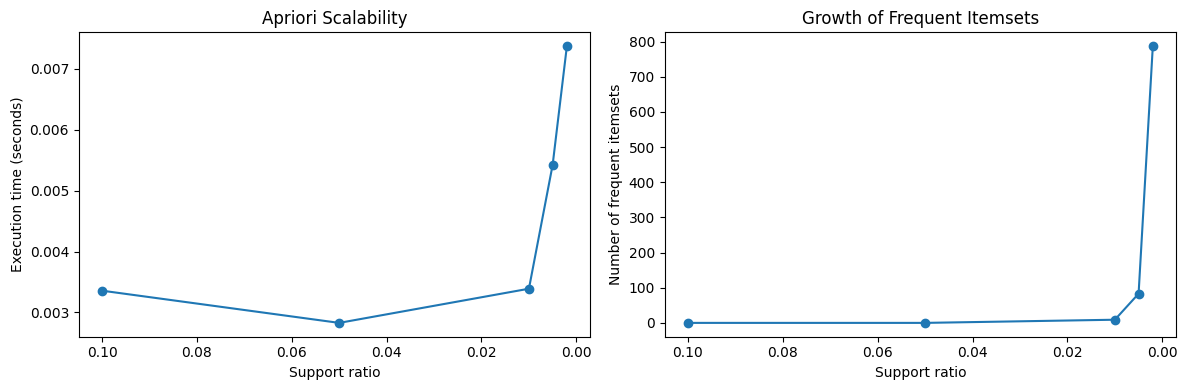

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Execution time
axes[0].plot(
    results_df["support_ratio"],
    results_df["execution_time"],
    marker="o"
)

axes[0].invert_xaxis()
axes[0].set_xlabel("Support ratio")
axes[0].set_ylabel("Execution time (seconds)")
axes[0].set_title("Apriori Scalability")

# Number of frequent itemsets
axes[1].plot(
    results_df["support_ratio"],
    results_df["total_itemsets"],
    marker="o"
)

axes[1].invert_xaxis()
axes[1].set_xlabel("Support ratio")
axes[1].set_ylabel("Number of frequent itemsets")
axes[1].set_title("Growth of Frequent Itemsets")

plt.tight_layout()
plt.show()